## Tabtransformer

#### 1. Imports

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import tqdm
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [15]:
#Reproductibilité
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

#### 2. Hyperparamètres alignés sur le papier original

In [16]:
CONFIG = {
    "embed_dim": 32,           
    "num_heads": 8,            
    "num_layers": 6,           
    "col_embed_ratio": 8,     
    "mlp_hidden_mults": (4, 2),
    "dropout": 0.1,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "batch_size": 512,
    "epochs": 100,
    "patience": 15,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}


#### 3. CHARGEMENT ET NETTOYAGE


In [17]:
DATA_PATH = "/kaggle/input/datasets/vvv35888/combinef/combine_UNSW_test3.csv"

if not os.path.exists(DATA_PATH):
    print("Erreur : Fichier introuvable. Vérifiez le chemin.")
else:
    print("[OK] Lecture du fichier...")
    df = pd.read_csv(DATA_PATH, on_bad_lines='skip', low_memory=False)
    print(f"   {df.shape[0]} lignes × {df.shape[1]} colonnes")

    def clean_dataset(df):
        df.columns = df.columns.str.strip()
        if 'attack_cat' in df.columns:
            df['attack_cat'] = df['attack_cat'].astype(str).str.strip()
            df['attack_cat'] = df['attack_cat'].replace({
                'Backdoors': 'Backdoor',
                'Fuzzers ': 'Fuzzers',
                ' Reconnaissance ': 'Reconnaissance',
                ' Shellcode ': 'Shellcode'
            })
        return df

    df = clean_dataset(df)


[OK] Lecture du fichier...
   321283 lignes × 22 colonnes


#### 4. Features

In [18]:
    TARGET_COL = 'attack_cat'
    CAT_COLS = ['proto', 'service', 'state']

    NUM_COLS = ['ct_srv_dst', 'sbytes', 'ct_dst_sport_ltm', 'smeansz','synack',
            'sload', 'ct_src_ltm', 'dttl', 'dmeansz',
            'dtcpb', 'stcpb', 'dbytes', 'sttl', 'ct_state_ttl',
            'dur', 'sjit', 'dload', 'sintpkt']

    # Vérification que toutes les colonnes existent
    missing = [c for c in CAT_COLS + NUM_COLS + [TARGET_COL] if c not in df.columns]
    if missing:
        print(f"⚠️ Colonnes manquantes : {missing}")
        print(f"   Colonnes disponibles : {list(df.columns)}")
    else:
        print(f"Toutes les colonnes trouvées")
    
# --- ENCODAGE CIBLE ---
    target_le = LabelEncoder()
    df[TARGET_COL] = target_le.fit_transform(df[TARGET_COL])
    NUM_CLASSES = len(target_le.classes_)
    class_names = target_le.classes_

    print(f"\n Distribution des classes :")
    for i, name in enumerate(class_names):
        count = (df[TARGET_COL] == i).sum()
        pct = 100 * count / len(df)
        print(f"   {name:20s} : {count:>7,} ({pct:5.1f}%)")

Toutes les colonnes trouvées

 Distribution des classes :
   Analysis             :   2,677 (  0.8%)
   Backdoor             :   2,329 (  0.7%)
   DoS                  :  16,353 (  5.1%)
   Exploits             :  44,525 ( 13.9%)
   Fuzzers              :  24,246 (  7.5%)
   Generic              : 215,481 ( 67.1%)
   Reconnaissance       :  13,987 (  4.4%)
   Shellcode            :   1,511 (  0.5%)
   Worms                :     174 (  0.1%)


#### 5. SPLIT : Train 70% / Val 15% / Test 15%

In [19]:
    df_train_val, df_test = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df[TARGET_COL]
    )
    df_train, df_val = train_test_split(
        df_train_val, test_size=0.1765,  # 0.1765 × 85% ≈ 15%
        random_state=42, stratify=df_train_val[TARGET_COL]
    )

    print(f"\n Split : Train {len(df_train):,} | Val {len(df_val):,} | Test {len(df_test):,}")



 Split : Train 224,889 | Val 48,201 | Test 48,193


#### 6. Encodage et normalisation

In [20]:
# --- ENCODAGE CATÉGORIEL ---
cat_encoders = {}
cat_dims = []

for col in CAT_COLS:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col].astype(str))
    col_map = dict(zip(le.classes_, le.transform(le.classes_)))

    mode_val = df_train[col].mode()[0]
    for d in [df_val, df_test]:
        d[col] = d[col].astype(str).apply(lambda x: col_map.get(x, mode_val))

    cat_encoders[col] = le
    cat_dims.append(len(le.classes_))
    print(f"   📋 {col}: {len(le.classes_)} catégories")

# --- NORMALISATION ---
scaler = StandardScaler()
df_train[NUM_COLS] = scaler.fit_transform(df_train[NUM_COLS])
df_val[NUM_COLS] = scaler.transform(df_val[NUM_COLS])
df_test[NUM_COLS] = scaler.transform(df_test[NUM_COLS])

# --- CLASS WEIGHTS ---
counts = np.bincount(df_train[TARGET_COL])
total_samples = len(df_train)
weights = total_samples / (NUM_CLASSES * np.sqrt(counts))
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(CONFIG['device'])

   📋 proto: 129 catégories
   📋 service: 13 catégories
   📋 state: 6 catégories


#### 7. ARCHITECTURE TABTRANSFORMER

In [21]:
class ColumnEmbedding(nn.Module):
    """
    Column Embedding (Papier Section 2) :
    e_phi(j) = [c_phi, w_phi_j]
    """
    def __init__(self, num_categories, embed_dim, col_embed_ratio=8):
        super().__init__()
        self.col_id_dim = embed_dim // col_embed_ratio
        self.val_dim = embed_dim - self.col_id_dim
        self.col_identifier = nn.Parameter(torch.randn(self.col_id_dim))
        self.value_embedding = nn.Embedding(num_categories + 1, self.val_dim)

    def forward(self, x):
        val_emb = self.value_embedding(x)
        col_id = self.col_identifier.unsqueeze(0).expand(x.size(0), -1)
        return torch.cat([col_id, val_emb], dim=-1)


class TabTransformerMulti(nn.Module):
    def __init__(self, cat_dims, num_continuous, num_classes, config):
        super().__init__()
        embed_dim = config['embed_dim']

        self.cat_embeddings = nn.ModuleList([
            ColumnEmbedding(n, embed_dim, config['col_embed_ratio'])
            for n in cat_dims
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=config['num_heads'],
            dim_feedforward=embed_dim * 4, dropout=config['dropout'],
            activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=config['num_layers']
        )

        self.num_ln = nn.LayerNorm(num_continuous)

        mlp_in = (len(cat_dims) * embed_dim) + num_continuous
        self.mlp = nn.Sequential(
            nn.Linear(mlp_in, mlp_in * config['mlp_hidden_mults'][0]),
            nn.SELU(),
            nn.BatchNorm1d(mlp_in * config['mlp_hidden_mults'][0]),
            nn.Dropout(config['dropout']),
            nn.Linear(mlp_in * config['mlp_hidden_mults'][0],
                      mlp_in * config['mlp_hidden_mults'][1]),
            nn.SELU(),
            nn.BatchNorm1d(mlp_in * config['mlp_hidden_mults'][1]),
            nn.Dropout(config['dropout']),
            nn.Linear(mlp_in * config['mlp_hidden_mults'][1], num_classes)
        )

    def forward(self, x_cat, x_num):
        x = torch.stack([
            emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)
        ], dim=1)
        x = self.transformer(x).flatten(start_dim=1)
        x_num = self.num_ln(x_num)
        return self.mlp(torch.cat([x, x_num], dim=1))

#### 8. DATALOADERS

    

In [22]:
class NetData(Dataset):
    def __init__(self, df):
        self.xc = torch.tensor(df[CAT_COLS].values, dtype=torch.long)
        self.xn = torch.tensor(df[NUM_COLS].values, dtype=torch.float32)
        self.y = torch.tensor(df[TARGET_COL].values, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.xc[i], self.xn[i], self.y[i]

train_loader = DataLoader(NetData(df_train), batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(NetData(df_val), batch_size=CONFIG['batch_size'])
test_loader = DataLoader(NetData(df_test), batch_size=CONFIG['batch_size'])

#### 9. Innitialisation

In [23]:
model = TabTransformerMulti(
    cat_dims, len(NUM_COLS), NUM_CLASSES, CONFIG
).to(CONFIG['device'])

optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n🏗️ Modèle : {total_params:,} paramètres")
print(f"📐 Transformer : {len(CAT_COLS)} tokens × {CONFIG['embed_dim']} dim × {CONFIG['num_layers']} layers")



🏗️ Modèle : 240,565 paramètres
📐 Transformer : 3 tokens × 32 dim × 6 layers


#### 10. Entrainement


--- Entraînement sur cuda---


Epoch 1: 100%|██████████| 440/440 [00:11<00:00, 39.53it/s, loss=1.0669]


  Train Loss: 1.0572 | Val Loss: 0.9210 | Macro-F1: 0.3721 | Acc: 0.8382
  ✅ Best model (F1=0.3721)


Epoch 2: 100%|██████████| 440/440 [00:11<00:00, 39.94it/s, loss=0.9433]


  Train Loss: 0.9433 | Val Loss: 0.8930 | Macro-F1: 0.3903 | Acc: 0.8377
  ✅ Best model (F1=0.3903)


...

  Train Loss: 0.6499 | Val Loss: 0.6271 | Macro-F1: 0.5369 | Acc: 0.8690
  ✅ Best model (F1=0.5369)


Epoch 99: 100%|██████████| 440/440 [00:11<00:00, 39.06it/s, loss=0.6504]


  Train Loss: 0.6489 | Val Loss: 0.6300 | Macro-F1: 0.5445 | Acc: 0.8686


Epoch 100: 100%|██████████| 440/440 [00:11<00:00, 38.72it/s, loss=0.6555]


  Train Loss: 0.6495 | Val Loss: 0.6296 | Macro-F1: 0.5370 | Acc: 0.8686

🔄 Best model restored (Val Macro-F1: 0.5369)


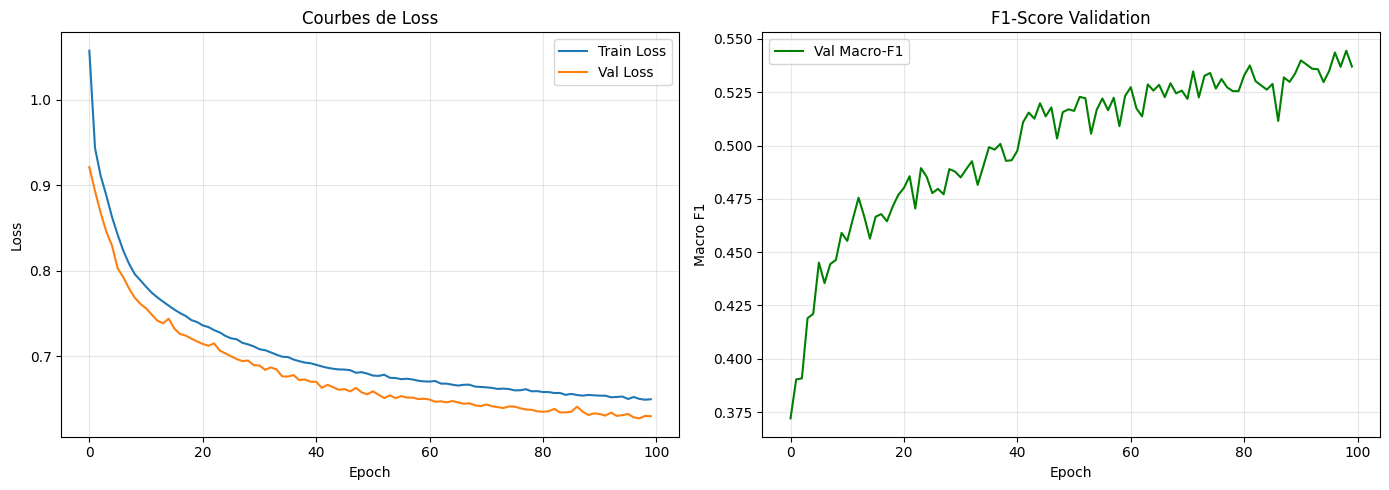

In [24]:
print(f"\n--- Entraînement sur {CONFIG['device']}---")

best_val_loss = float('inf')
best_val_f1 = 0.0
patience_counter = 0
best_model_state = None
train_losses, val_losses, val_f1_scores = [], [], []

for epoch in range(CONFIG['epochs']):
    model.train()
    total_loss = 0
    tk0 = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for xc, xn, y in tk0:
        xc, xn, y = xc.to(CONFIG['device']), xn.to(CONFIG['device']), y.to(CONFIG['device'])
        optimizer.zero_grad()
        out = model(xc, xn)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        tk0.set_postfix(loss=f"{total_loss / (tk0.n + 1):.4f}")

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for xc, xn, y in val_loader:
            xc, xn, y = xc.to(CONFIG['device']), xn.to(CONFIG['device']), y.to(CONFIG['device'])
            out = model(xc, xn)
            val_loss += criterion(out, y).item()
            val_preds.extend(out.argmax(1).cpu().numpy())
            val_targets.extend(y.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_f1 = f1_score(val_targets, val_preds, average='macro')
    val_acc = accuracy_score(val_targets, val_preds)
    val_f1_scores.append(val_f1)

    scheduler.step(avg_val_loss)

    print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Macro-F1: {val_f1:.4f} | Acc: {val_acc:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_val_f1 = val_f1
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  ✅ Best model (F1={val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f"\n⛔ Early stopping epoch {epoch+1}")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n🔄 Best model restored (Val Macro-F1: {best_val_f1:.4f})")


# COURBES D'APPRENTISSAGE

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Courbes de Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(val_f1_scores, label='Val Macro-F1', color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
ax2.set_title('F1-Score Validation'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

#### 11. ÉVALUATION FINALE


📊 RAPPORT FINAL SUR TEST SET
                precision    recall  f1-score   support

      Analysis       0.36      0.27      0.31       402
      Backdoor       0.12      0.07      0.09       349
           DoS       0.33      0.73      0.46      2453
      Exploits       0.79      0.53      0.63      6679
       Fuzzers       0.83      0.81      0.82      3637
       Generic       1.00      0.97      0.99     32322
Reconnaissance       0.78      0.80      0.79      2098
     Shellcode       0.37      0.70      0.48       227
         Worms       0.13      0.54      0.22        26

      accuracy                           0.87     48193
     macro avg       0.52      0.60      0.53     48193
  weighted avg       0.90      0.87      0.87     48193

🎯 Accuracy: 0.8668 | Macro-F1: 0.5311 | Weighted-F1: 0.8748


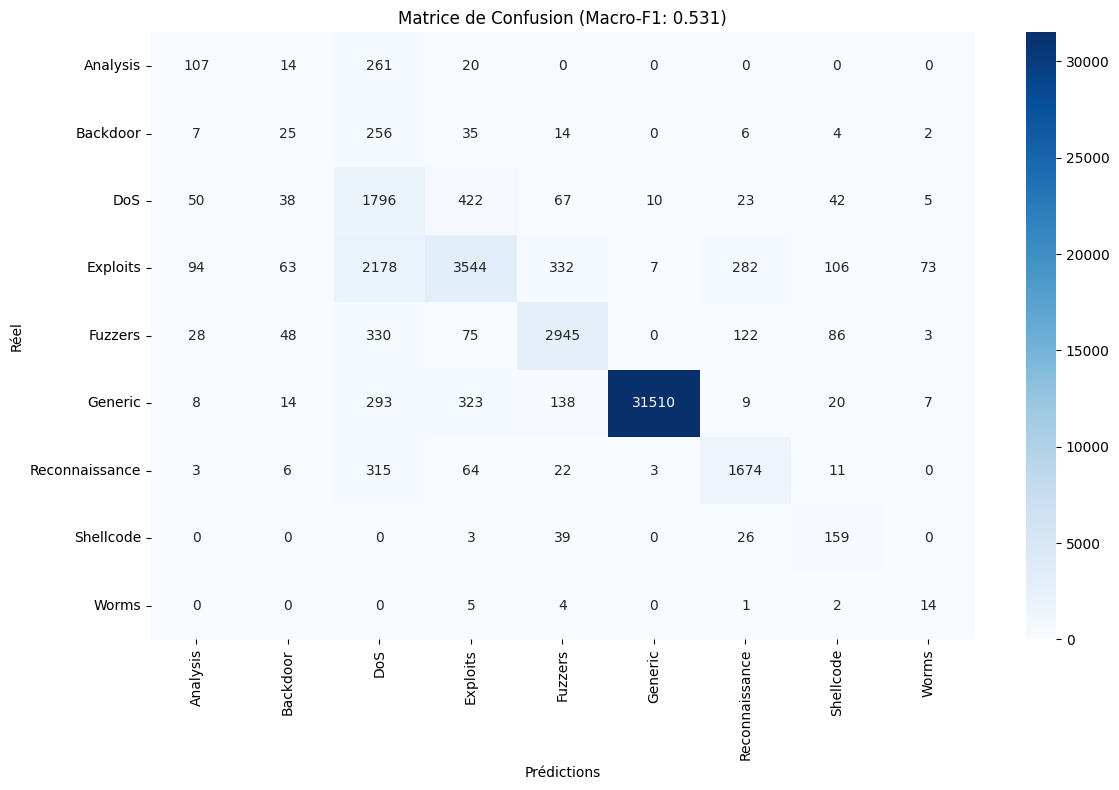

In [25]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for xc, xn, y in test_loader:
        out = model(xc.to(CONFIG['device']), xn.to(CONFIG['device']))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())

print("\n" + "=" * 60)
print("📊 RAPPORT FINAL SUR TEST SET")
print("=" * 60)
print(classification_report(all_targets, all_preds, target_names=class_names))

macro_f1 = f1_score(all_targets, all_preds, average='macro')
weighted_f1 = f1_score(all_targets, all_preds, average='weighted')
acc = accuracy_score(all_targets, all_preds)
print(f"🎯 Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}")

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matrice de Confusion (Macro-F1: {macro_f1:.3f})')
plt.xlabel('Prédictions'); plt.ylabel('Réel')
plt.tight_layout(); plt.show()

### COURBES ROC ET PR

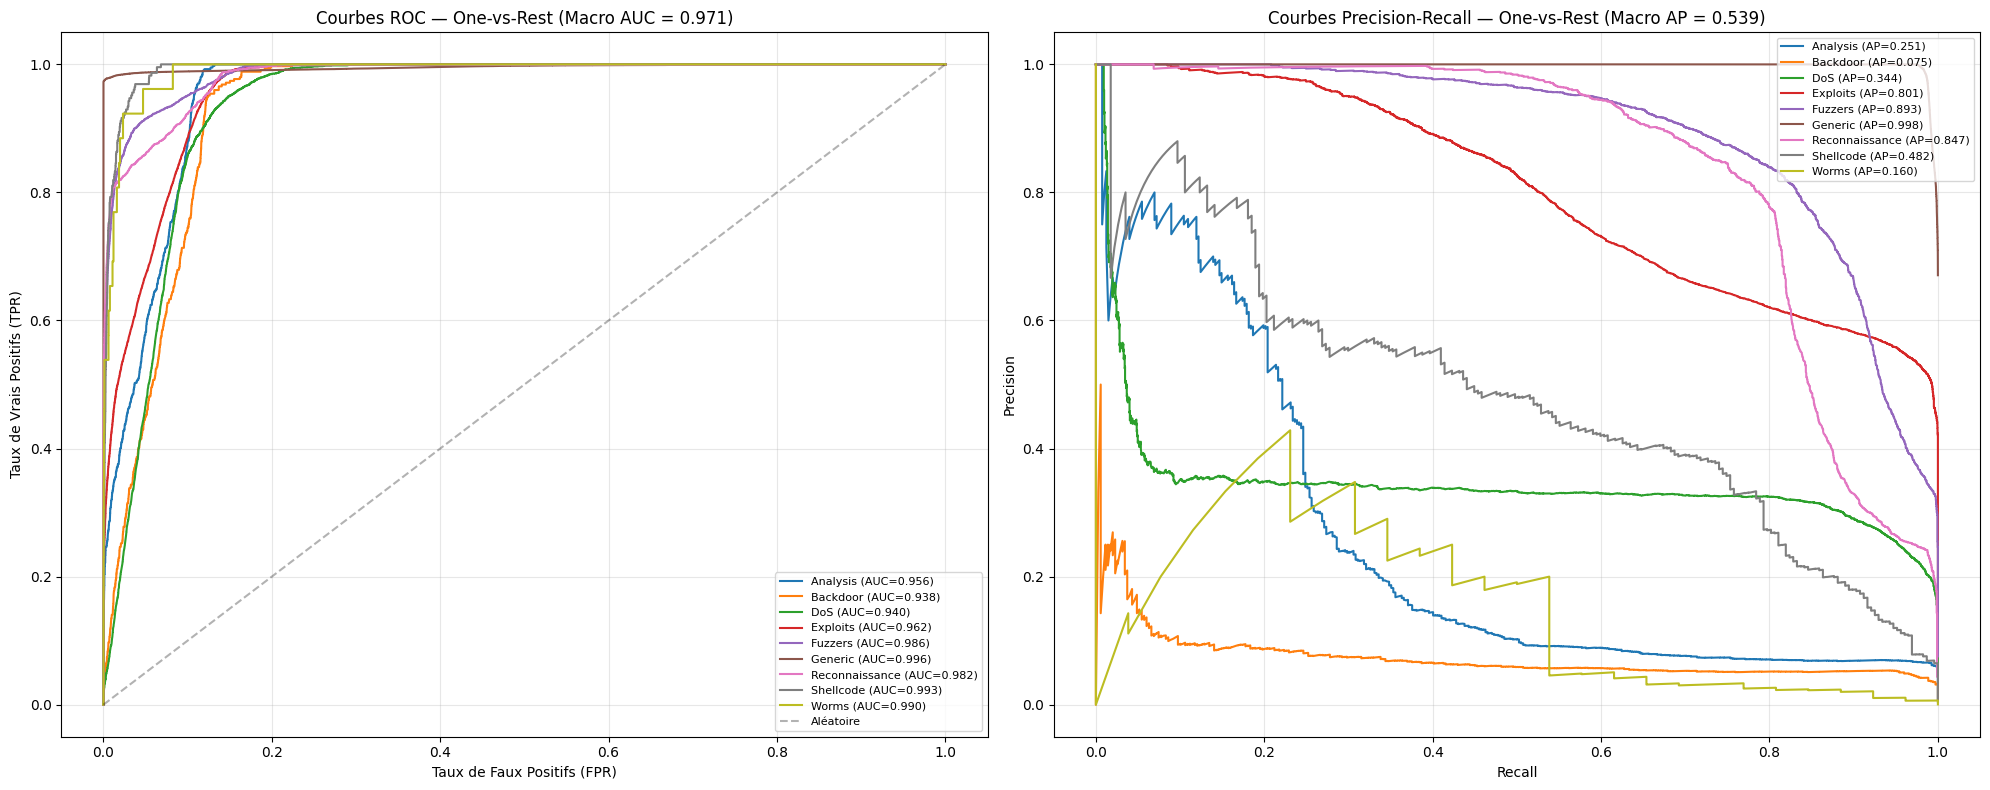


📊 Résumé AUC / AP par classe :
Classe                  ROC-AUC      PR-AP
------------------------------------------
Analysis                 0.9558     0.2506
Backdoor                 0.9379     0.0749
DoS                      0.9396     0.3436
Exploits                 0.9624     0.8007
Fuzzers                  0.9860     0.8929
Generic                  0.9956     0.9982
Reconnaissance           0.9816     0.8466
Shellcode                0.9928     0.4818
Worms                    0.9897     0.1599
------------------------------------------
Macro-Moyenne            0.9713     0.5388


In [26]:


from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

# --- Récupérer les probabilités ---
model.eval()
all_probs, all_targets = [], []
with torch.no_grad():
    for xc, xn, y in test_loader:
        out = model(xc.to(CONFIG['device']), xn.to(CONFIG['device']))
        probs = F.softmax(out, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_targets.extend(y.numpy())

all_probs = np.vstack(all_probs)
all_targets = np.array(all_targets)

# Binariser les labels pour le calcul OvR
y_bin = label_binarize(all_targets, classes=range(NUM_CLASSES))

# --- COURBES ROC ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ROC par classe
ax = axes[0]
roc_aucs = {}
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    roc_aucs[name] = roc_auc
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aléatoire')
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title('Courbes ROC — One-vs-Rest')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# ROC macro-moyenne
mean_auc = np.mean(list(roc_aucs.values()))
ax.set_title(f'Courbes ROC — One-vs-Rest (Macro AUC = {mean_auc:.3f})')

# --- COURBES PR ---
ax = axes[1]
pr_aucs = {}
for i, name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
    ap = average_precision_score(y_bin[:, i], all_probs[:, i])
    pr_aucs[name] = ap
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f})')

# Baseline : proportion de chaque classe
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
mean_ap = np.mean(list(pr_aucs.values()))
ax.set_title(f'Courbes Precision-Recall — One-vs-Rest (Macro AP = {mean_ap:.3f})')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Résumé ---
print("\n📊 Résumé AUC / AP par classe :")
print(f"{'Classe':20s} {'ROC-AUC':>10s} {'PR-AP':>10s}")
print("-" * 42)
for name in class_names:
    print(f"{name:20s} {roc_aucs[name]:>10.4f} {pr_aucs[name]:>10.4f}")
print("-" * 42)
print(f"{'Macro-Moyenne':20s} {mean_auc:>10.4f} {mean_ap:>10.4f}")

### ATTENTION MAPS DU TABTRANSFORMER

Visualise ce que le Transformer "regarde" :
quelles features catégorielles sont liées entre elles
pour chaque type d'attaque.

Échantillons collectés par classe :
   Analysis             : 200 samples
   Backdoor             : 200 samples
   DoS                  : 200 samples
   Exploits             : 200 samples
   Fuzzers              : 200 samples
   Generic              : 200 samples
   Reconnaissance       : 200 samples
   Shellcode            : 200 samples
   Worms                : 26 samples


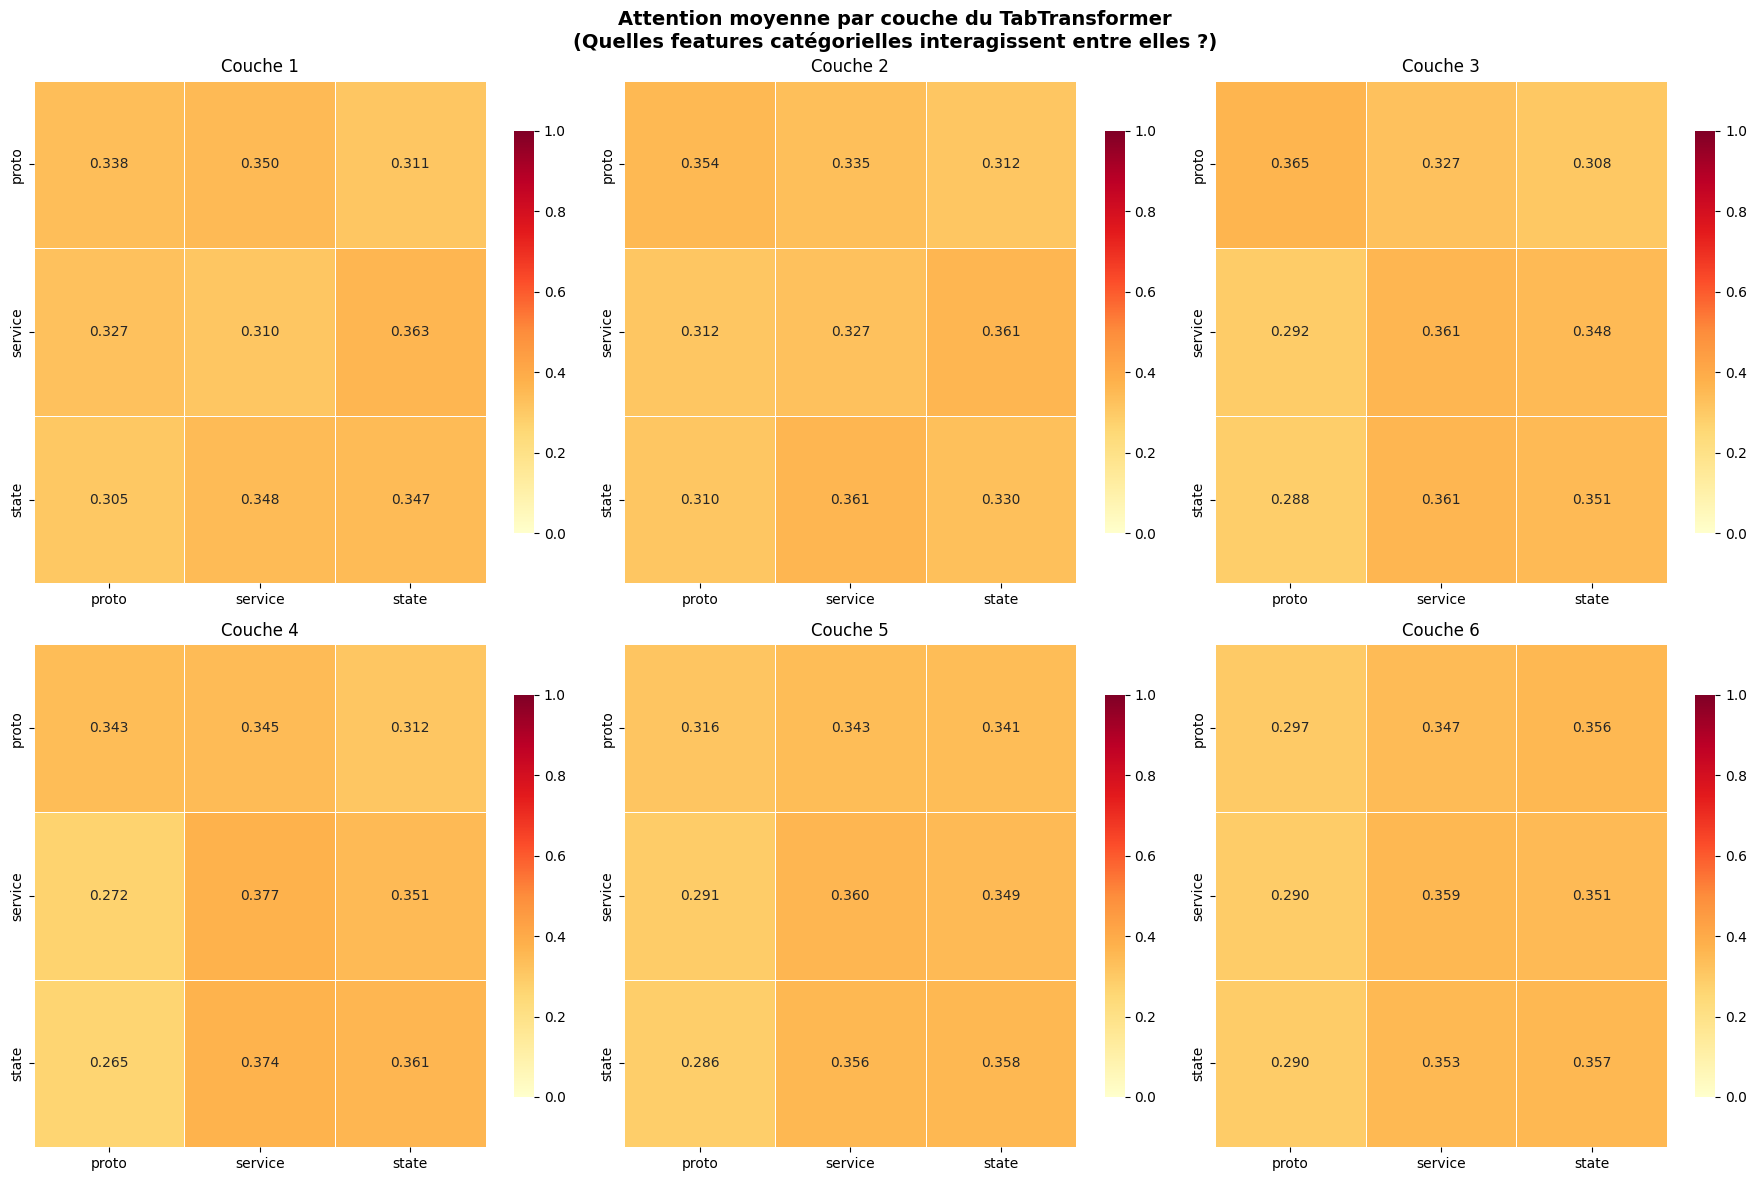

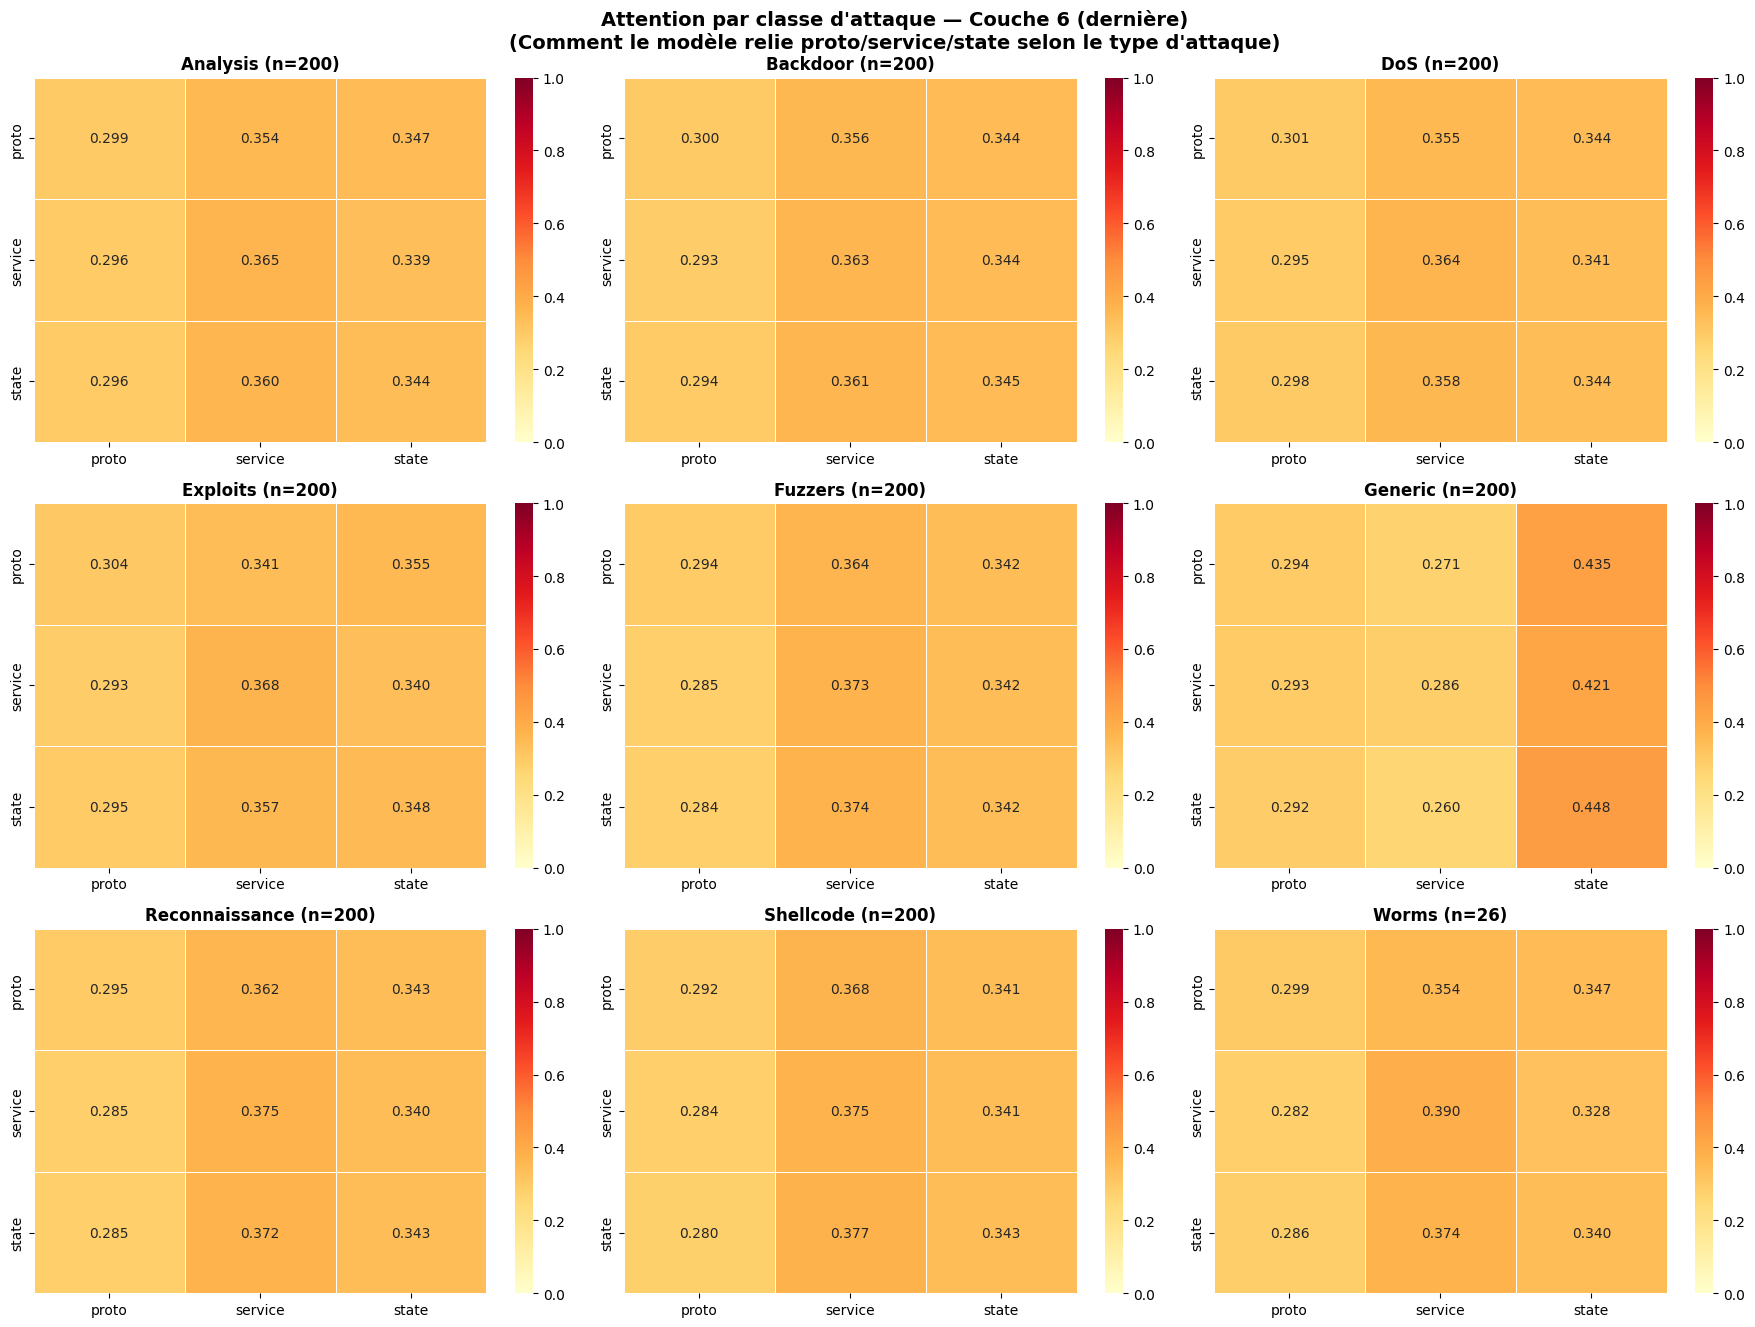


📊 Score d'attention moyen (dernière couche) par classe :
Classe                  proto→svc  proto→state    svc→state
----------------------------------------------------------
Analysis                   0.3541       0.3467       0.3390
Backdoor                   0.3563       0.3440       0.3443
DoS                        0.3551       0.3444       0.3411
Exploits                   0.3408       0.3551       0.3398
Fuzzers                    0.3643       0.3417       0.3419
Generic                    0.2709       0.4354       0.4213
Reconnaissance             0.3623       0.3431       0.3402
Shellcode                  0.3676       0.3408       0.3415
Worms                      0.3544       0.3467       0.3281


In [27]:
# --- Extraire les poids d'attention avec des hooks ---
attention_weights = []

def hook_fn(module, input, output):
    """Capture les poids d'attention de chaque couche."""
    # output[1] contient les attention weights si on active need_weights
    pass

# On utilise une approche directe : forward manuel avec need_weights
model.eval()

# Récupérer les attention weights manuellement
def get_attention_weights(model, x_cat, x_num):
    """Forward pass qui retourne les attention weights de chaque couche."""
    # 1. Embeddings catégoriels
    x = torch.stack([
        emb(x_cat[:, i]) for i, emb in enumerate(model.cat_embeddings)
    ], dim=1)

    # 2. Passer dans chaque couche du Transformer en récupérant l'attention
    layer_attentions = []
    for layer in model.transformer.layers:
        # Self-attention avec need_weights=True
        attn_out, attn_weights = layer.self_attn(
            x, x, x, need_weights=True, average_attn_weights=False
        )
        layer_attentions.append(attn_weights.detach().cpu().numpy())

        # Compléter le forward de la couche (feedforward + residuals)
        x = layer.norm1(x + layer.dropout1(attn_out))
        ff_out = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
        x = layer.norm2(x + layer.dropout2(ff_out))

    return layer_attentions  # Liste de (batch, num_heads, n_tokens, n_tokens)

# --- Collecter les attentions par classe d'attaque ---
from collections import defaultdict

class_attentions = defaultdict(list)
max_samples_per_class = 200  # Suffisant pour une moyenne stable

model.eval()
with torch.no_grad():
    for xc, xn, y in test_loader:
        xc_dev = xc.to(CONFIG['device'])
        xn_dev = xn.to(CONFIG['device'])

        layer_attns = get_attention_weights(model, xc_dev, xn_dev)

        preds = model(xc_dev, xn_dev).argmax(1).cpu().numpy()
        targets = y.numpy()

        for idx in range(len(targets)):
            cls = targets[idx]
            if len(class_attentions[cls]) < max_samples_per_class:
                # Moyenne sur les heads, garder toutes les couches
                sample_attn = [layer[idx].mean(axis=0) for layer in layer_attns]
                class_attentions[cls].append(sample_attn)

print(f"Échantillons collectés par classe :")
for cls_id in sorted(class_attentions.keys()):
    print(f"   {class_names[cls_id]:20s} : {len(class_attentions[cls_id])} samples")

# --- Visualisation 1 : Attention moyenne par couche (toutes classes) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

token_names = CAT_COLS  # ['proto', 'service', 'state']

# Moyenne globale par couche
all_samples = []
for cls_samples in class_attentions.values():
    all_samples.extend(cls_samples)

for layer_idx in range(min(6, CONFIG['num_layers'])):
    ax = axes[layer_idx]
    layer_mean = np.mean([s[layer_idx] for s in all_samples], axis=0)

    sns.heatmap(layer_mean, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=token_names, yticklabels=token_names,
                vmin=0, vmax=1, ax=ax, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Couche {layer_idx + 1}')

plt.suptitle('Attention moyenne par couche du TabTransformer\n'
             '(Quelles features catégorielles interagissent entre elles ?)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Visualisation 2 : Attention par classe (dernière couche) ---
n_classes = len(class_attentions)
cols = 3
rows = (n_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4.5))
axes = axes.flatten()

last_layer = CONFIG['num_layers'] - 1

for i, cls_id in enumerate(sorted(class_attentions.keys())):
    ax = axes[i]
    cls_samples = class_attentions[cls_id]

    if len(cls_samples) > 0:
        attn_mean = np.mean([s[last_layer] for s in cls_samples], axis=0)

        sns.heatmap(attn_mean, annot=True, fmt='.3f', cmap='YlOrRd',
                    xticklabels=token_names, yticklabels=token_names,
                    vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(f'{class_names[cls_id]} (n={len(cls_samples)})', fontweight='bold')

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Attention par classe d\'attaque — Couche {last_layer + 1} (dernière)\n'
             f'(Comment le modèle relie proto/service/state selon le type d\'attaque)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Visualisation 3 : Différence d'attention entre classes ---
# Quelle classe utilise le plus chaque paire de features ?
print("\n📊 Score d'attention moyen (dernière couche) par classe :")
print(f"{'Classe':20s} {'proto→svc':>12s} {'proto→state':>12s} {'svc→state':>12s}")
print("-" * 58)
for cls_id in sorted(class_attentions.keys()):
    cls_samples = class_attentions[cls_id]
    if len(cls_samples) > 0:
        attn = np.mean([s[last_layer] for s in cls_samples], axis=0)
        print(f"{class_names[cls_id]:20s} {attn[0,1]:>12.4f} {attn[0,2]:>12.4f} {attn[1,2]:>12.4f}")

### TESTS DE ROBUSTESSE
Deux tests pour évaluer la stabilité du TabTransformer :
* Sous-sampling : entraîner avec 25%, 50%, 75%, 100% des données
* Sensibilité au bruit : ajouter du bruit gaussien sur les features numériques


### Tests de robustesse

🔬 TEST A : SOUS-SAMPLING (stabilité avec moins de données)
Entraînement avec 25%, 50%, 75%, 100% des données de train

   25% (56,222 lignes)            → Macro-F1 = 0.4509 | Acc = 0.8553
   50% (112,444 lignes)           → Macro-F1 = 0.4682 | Acc = 0.8602
   75% (168,667 lignes)           → Macro-F1 = 0.4861 | Acc = 0.8634
   100% (224,889 lignes)          → Macro-F1 = 0.5004 | Acc = 0.8605


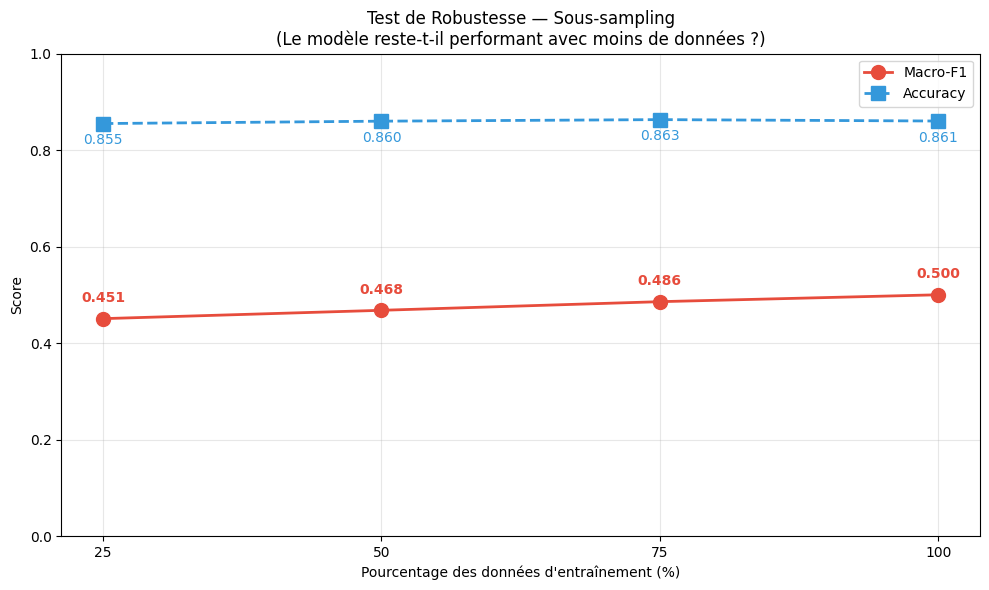


🔬 TEST B : SENSIBILITÉ AU BRUIT (robustesse aux perturbations)
Ajout de bruit gaussien sur les features numériques du test set

   Sans bruit (baseline)          → Macro-F1 = 0.5311 | Acc = 0.8668
   σ = 0.05                       → Macro-F1 = 0.4698 | Acc = 0.8505
   σ = 0.10                       → Macro-F1 = 0.4034 | Acc = 0.8192
   σ = 0.20                       → Macro-F1 = 0.3340 | Acc = 0.7482
   σ = 0.30                       → Macro-F1 = 0.2946 | Acc = 0.6906


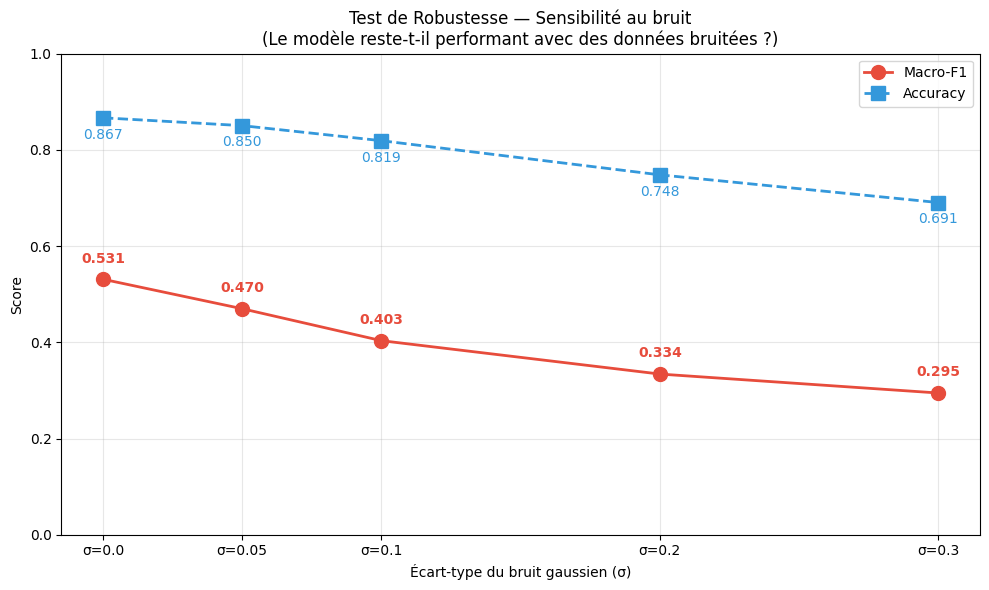


📊 RÉSUMÉ DES TESTS DE ROBUSTESSE

A) Sous-sampling :
    25% ( 56,222 lignes) : Macro-F1 = 0.4509  (Δ = +9.9%)
    50% (112,444 lignes) : Macro-F1 = 0.4682  (Δ = +6.4%)
    75% (168,667 lignes) : Macro-F1 = 0.4861  (Δ = +2.9%)
   100% (224,889 lignes) : Macro-F1 = 0.5004  (Δ = +0.0%)

B) Sensibilité au bruit :
   σ = 0.00 : Macro-F1 = 0.5311  (Δ = +0.0%)
   σ = 0.05 : Macro-F1 = 0.4698  (Δ = +11.5%)
   σ = 0.10 : Macro-F1 = 0.4034  (Δ = +24.0%)
   σ = 0.20 : Macro-F1 = 0.3340  (Δ = +37.1%)
   σ = 0.30 : Macro-F1 = 0.2946  (Δ = +44.5%)


In [28]:
import copy

# --- Fonction d'entraînement ---
def train_and_evaluate(train_df, val_df, test_df, config, label=""):
    """Entraîne un TabTransformer et retourne les métriques sur le test set."""
    train_loader = DataLoader(NetData(train_df), batch_size=config['batch_size'], shuffle=True)
    val_loader_r = DataLoader(NetData(val_df), batch_size=config['batch_size'])
    test_loader_r = DataLoader(NetData(test_df), batch_size=config['batch_size'])

    m = TabTransformerMulti(
        cat_dims, len(NUM_COLS), NUM_CLASSES, config
    ).to(config['device'])

    opt = optim.AdamW(m.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=5, factor=0.5)
    crit = nn.CrossEntropyLoss(weight=weights_tensor)

    best_state = None
    best_loss = float('inf')
    EPOCHS_ROBUST = 50  

    for epoch in range(EPOCHS_ROBUST):
        m.train()
        t_loss = 0
        for xc, xn, y in train_loader:
            xc, xn, y = xc.to(config['device']), xn.to(config['device']), y.to(config['device'])
            opt.zero_grad()
            out = m(xc, xn)
            loss = crit(out, y)
            loss.backward()
            opt.step()
            t_loss += loss.item()

        m.eval()
        v_loss = 0
        with torch.no_grad():
            for xc, xn, y in val_loader_r:
                xc, xn, y = xc.to(config['device']), xn.to(config['device']), y.to(config['device'])
                v_loss += crit(m(xc, xn), y).item()

        avg_v = v_loss / len(val_loader_r)
        sch.step(avg_v)

        if avg_v < best_loss:
            best_loss = avg_v
            best_state = {k: v.clone() for k, v in m.state_dict().items()}

    if best_state:
        m.load_state_dict(best_state)

    # Évaluation sur test
    m.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xc, xn, y in test_loader_r:
            out = m(xc.to(config['device']), xn.to(config['device']))
            preds.extend(out.argmax(1).cpu().numpy())
            targets.extend(y.numpy())

    macro = f1_score(targets, preds, average='macro')
    acc = accuracy_score(targets, preds)
    print(f"   {label:30s} → Macro-F1 = {macro:.4f} | Acc = {acc:.4f}")
    return macro, acc

# ==========================================
# 11A. TEST DE SOUS-SAMPLING
# ==========================================
print("=" * 60)
print("🔬 TEST A : SOUS-SAMPLING (stabilité avec moins de données)")
print("=" * 60)
print("Entraînement avec 25%, 50%, 75%, 100% des données de train\n")

fractions = [0.25, 0.50, 0.75, 1.0]
subsample_results = []

for frac in fractions:
    if frac < 1.0:
        df_sub = df_train.sample(frac=frac, random_state=42)
    else:
        df_sub = df_train.copy()

    label = f"{int(frac*100)}% ({len(df_sub):,} lignes)"
    macro, acc = train_and_evaluate(df_sub, df_val, df_test, CONFIG, label)
    subsample_results.append((frac, len(df_sub), macro, acc))

# --- Graphique sous-sampling ---
fig, ax = plt.subplots(figsize=(10, 6))
fracs = [r[0]*100 for r in subsample_results]
f1s = [r[2] for r in subsample_results]
accs = [r[3] for r in subsample_results]

ax.plot(fracs, f1s, 'o-', color='#e74c3c', linewidth=2, markersize=10, label='Macro-F1')
ax.plot(fracs, accs, 's--', color='#3498db', linewidth=2, markersize=10, label='Accuracy')

for i, (f, f1, a) in enumerate(zip(fracs, f1s, accs)):
    ax.annotate(f'{f1:.3f}', (f, f1), textcoords="offset points",
                xytext=(0, 12), ha='center', fontweight='bold', color='#e74c3c')
    ax.annotate(f'{a:.3f}', (f, a), textcoords="offset points",
                xytext=(0, -15), ha='center', color='#3498db')

ax.set_xlabel('Pourcentage des données d\'entraînement (%)')
ax.set_ylabel('Score')
ax.set_title('Test de Robustesse — Sous-sampling\n(Le modèle reste-t-il performant avec moins de données ?)')
ax.set_xticks(fracs)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# ==========================================
# 11B. TEST DE SENSIBILITÉ AU BRUIT
# ==========================================
print("\n" + "=" * 60)
print("🔬 TEST B : SENSIBILITÉ AU BRUIT (robustesse aux perturbations)")
print("=" * 60)
print("Ajout de bruit gaussien sur les features numériques du test set\n")

noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30]
noise_results = []

# On utilise le modèle déjà entraîné
model.eval()

for noise_std in noise_levels:
    # Copier le test set et ajouter du bruit
    df_test_noisy = df_test.copy()
    if noise_std > 0:
        noise = np.random.normal(0, noise_std, size=df_test_noisy[NUM_COLS].shape)
        df_test_noisy[NUM_COLS] = df_test_noisy[NUM_COLS].values + noise

    test_loader_noisy = DataLoader(NetData(df_test_noisy), batch_size=CONFIG['batch_size'])

    preds, targets = [], []
    with torch.no_grad():
        for xc, xn, y in test_loader_noisy:
            out = model(xc.to(CONFIG['device']), xn.to(CONFIG['device']))
            preds.extend(out.argmax(1).cpu().numpy())
            targets.extend(y.numpy())

    macro = f1_score(targets, preds, average='macro')
    acc = accuracy_score(targets, preds)
    label = f"σ = {noise_std:.2f}" if noise_std > 0 else "Sans bruit (baseline)"
    print(f"   {label:30s} → Macro-F1 = {macro:.4f} | Acc = {acc:.4f}")
    noise_results.append((noise_std, macro, acc))

# --- Graphique bruit ---
fig, ax = plt.subplots(figsize=(10, 6))
noise_lvls = [r[0] for r in noise_results]
f1s = [r[1] for r in noise_results]
accs = [r[2] for r in noise_results]

ax.plot(noise_lvls, f1s, 'o-', color='#e74c3c', linewidth=2, markersize=10, label='Macro-F1')
ax.plot(noise_lvls, accs, 's--', color='#3498db', linewidth=2, markersize=10, label='Accuracy')

for i, (n, f1, a) in enumerate(zip(noise_lvls, f1s, accs)):
    ax.annotate(f'{f1:.3f}', (n, f1), textcoords="offset points",
                xytext=(0, 12), ha='center', fontweight='bold', color='#e74c3c')
    ax.annotate(f'{a:.3f}', (n, a), textcoords="offset points",
                xytext=(0, -15), ha='center', color='#3498db')

ax.set_xlabel('Écart-type du bruit gaussien (σ)')
ax.set_ylabel('Score')
ax.set_title('Test de Robustesse — Sensibilité au bruit\n(Le modèle reste-t-il performant avec des données bruitées ?)')
ax.set_xticks(noise_lvls)
ax.set_xticklabels([f'σ={n}' for n in noise_lvls])
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# --- Résumé global ---
print("\n" + "=" * 60)
print("📊 RÉSUMÉ DES TESTS DE ROBUSTESSE")
print("=" * 60)

print("\nA) Sous-sampling :")
baseline_f1 = subsample_results[-1][2]  # 100%
for frac, n, macro, acc in subsample_results:
    drop = ((baseline_f1 - macro) / baseline_f1) * 100
    print(f"   {int(frac*100):3d}% ({n:>7,} lignes) : Macro-F1 = {macro:.4f}  (Δ = {drop:+.1f}%)")

print("\nB) Sensibilité au bruit :")
baseline_f1_noise = noise_results[0][1]  # Sans bruit
for noise_std, macro, acc in noise_results:
    drop = ((baseline_f1_noise - macro) / baseline_f1_noise) * 100
    print(f"   σ = {noise_std:.2f} : Macro-F1 = {macro:.4f}  (Δ = {drop:+.1f}%)")